In [1]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
%matplotlib inline

data = pd.read_csv('Fuzzy Logic-Based Expert System.csv')

percentage = 0.3
data[:int(len(data)*percentage):]

,Time,Speed1,Lat1,Lon1,E1,N1,Speed2,Lat2,Lon2,Alt2,E2,N2,U2,IVS1,Driver2
0,55287.1,0.171824,0.798824,0.151472,21527.405914,67543.582167,0.015,0.798825,0.151473,312.172,21530.105172,67556.368671,-230.598343,7.468309,ACC
1,55287.2,0.210408,0.798824,0.151472,21527.406042,67543.545120,0.022,0.798825,0.151473,312.170,21530.105166,67556.368650,-230.600343,7.504510,ACC
2,55287.3,0.279343,0.798824,0.151472,21527.406106,67543.526597,0.012,0.798825,0.151473,312.174,21530.112958,67556.368719,-230.596369,7.524296,ACC
3,55287.4,0.365770,0.798824,0.151472,21527.393270,67543.489506,0.027,0.798825,0.151473,312.174,21530.112958,67556.368719,-230.596369,7.563238,ACC
4,55287.5,0.458884,0.798824,0.151472,21527.393463,67543.433936,0.043,0.798825,0.151473,312.177,21530.105189,67556.368724,-230.593343,7.615983,ACC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
754,55362.5,23.143827,0.798577,0.151443,21402.252061,65971.506725,23.298,0.798581,0.151447,310.774,21420.278695,66001.826172,-215.324884,29.673623,ACC
755,55362.6,23.116561,0.798577,0.151443,21400.961963,65969.575885,23.264,0.798581,0.151447,310.784,21419.157530,65999.788472,-215.290004,29.668670,ACC
756,55362.7,23.126336,0.798576,0.151443,21399.684767,65967.663613,23.233,0.798581,0.151446,310.762,21418.005057,65997.772564,-215.287248,29.644602,ACC
757,55362.8,23.140226,0.798576,0.151442,21398.381699,65965.732729,23.221,0.798580,0.151446,310.767,21416.860493,65995.745847,-215.257406,29.645611,ACC


Columns description: 
- Time: Common time frame for all vehicles (s) 
- Speed: Raw Speed (Doppler) (m/s) 
- Lat: Latitude (rad) 
- Lon: Longitude (rad) 
- Alt: Altitude (m) 
- E: East (x) coordinate in the local ENU plane (common center for all vehicles) (m) 
- N: North (y) coordinate in the local ENU plane (common center for all vehicles) (m) 
- U: Up (z) coordinate in the local ENU plane (common center for all vehicles) (m) 
- IVS: Inter Vehicle Spacing computed from GNSS data after bumper to bumper correction (m) 
- Driver: The driver of the vehicle: “Human” for manual driving, “ACC” for ACC driving as measured from OBD(acceleration pedal position)

In [3]:
# remove unused columns
data = data.drop(columns=['Time','Lat1','Lon1','Lat2','Lon2','Driver2'])

# save data to csv
data.to_csv('cleaned_data_fuzzy_logic.csv', index=False)

c:\Users\Malv\Downloads\class\ai lab\ai-venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


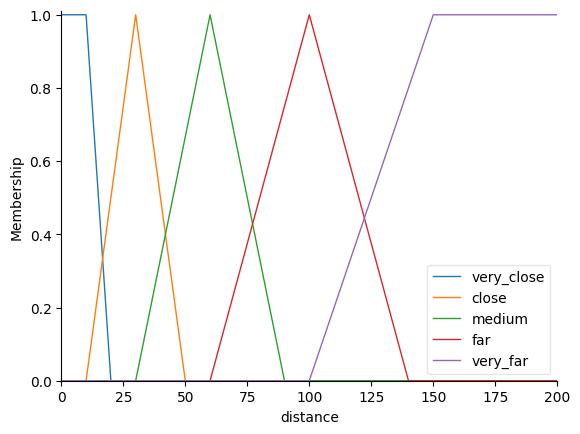

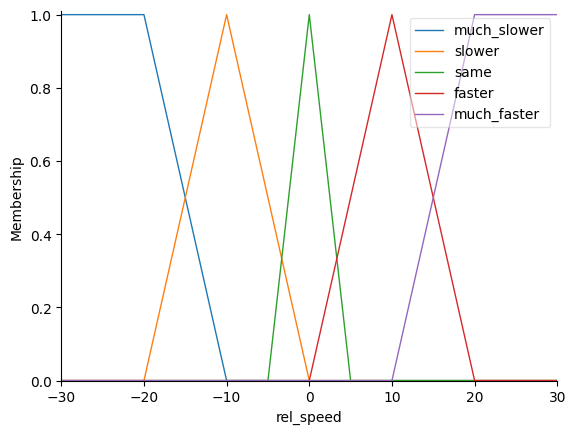

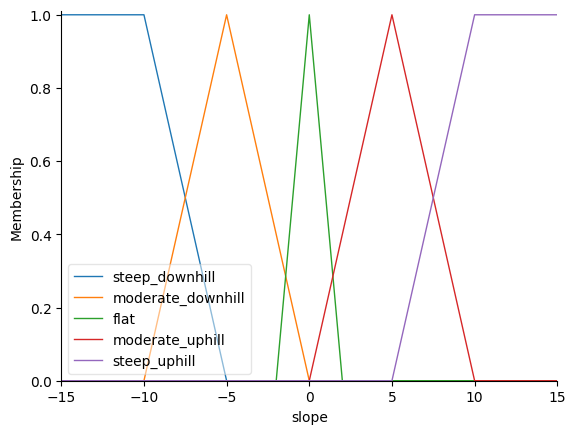

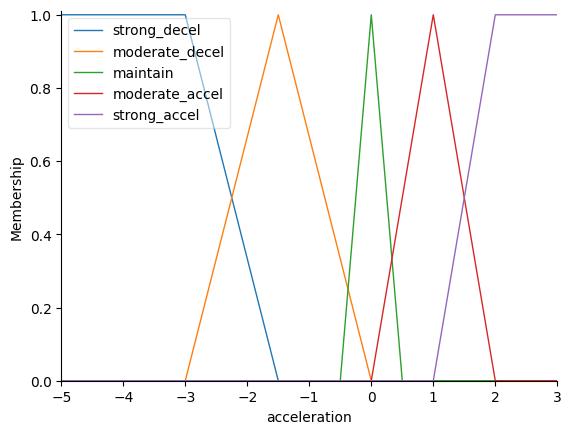

In [4]:
# Load cleaned data
data = pd.read_csv('cleaned_data_fuzzy_logic.csv')

# Calculate relative speed in km/h
data['rel_speed'] = (data['Speed2'] - data['Speed1']) * 3.6

# Calculate road slope
data['slope'] = 0.0  # Initialize with zeros

# Calculate slope between consecutive points
for i in range(1, len(data)):
    # Calculate horizontal distance between consecutive points
    delta_e = data.loc[i, 'E2'] - data.loc[i-1, 'E2']
    delta_n = data.loc[i, 'N2'] - data.loc[i-1, 'N2']
    horizontal_dist = np.sqrt(delta_e**2 + delta_n**2)
    
    # Calculate vertical distance
    delta_u = data.loc[i, 'U2'] - data.loc[i-1, 'U2']
    
    # Calculate slope in degrees and clip to [-15, 15] range
    if horizontal_dist > 0:
        slope_rad = np.arctan(delta_u / horizontal_dist)
        # Clip the slope to our defined universe
        data.loc[i, 'slope'] = np.clip(np.degrees(slope_rad), -15, 15)
    else:
        data.loc[i, 'slope'] = 0.0

# Distance (D) - Universe: [0, 200] meters
distance = ctrl.Antecedent(np.arange(0, 201, 1), 'distance')
distance['very_close'] = fuzz.trapmf(distance.universe, [0, 0, 10, 20])
distance['close'] = fuzz.trimf(distance.universe, [10, 30, 50])
distance['medium'] = fuzz.trimf(distance.universe, [30, 60, 90])
distance['far'] = fuzz.trimf(distance.universe, [60, 100, 140])
distance['very_far'] = fuzz.trapmf(distance.universe, [100, 150, 200, 200])

# Relative Speed (ΔV) - Universe: [-30, 30] km/h
rel_speed = ctrl.Antecedent(np.arange(-30, 31, 1), 'rel_speed')
rel_speed['much_slower'] = fuzz.trapmf(rel_speed.universe, [-30, -30, -20, -10])
rel_speed['slower'] = fuzz.trimf(rel_speed.universe, [-20, -10, 0])
rel_speed['same'] = fuzz.trimf(rel_speed.universe, [-5, 0, 5])
rel_speed['faster'] = fuzz.trimf(rel_speed.universe, [0, 10, 20])
rel_speed['much_faster'] = fuzz.trapmf(rel_speed.universe, [10, 20, 30, 30])

# Road Slope (S) - Universe: [-15, 15] degrees
slope = ctrl.Antecedent(np.arange(-15, 16, 1), 'slope')
slope['steep_downhill'] = fuzz.trapmf(slope.universe, [-15, -15, -10, -5])
slope['moderate_downhill'] = fuzz.trimf(slope.universe, [-10, -5, 0])
slope['flat'] = fuzz.trimf(slope.universe, [-2, 0, 2])
slope['moderate_uphill'] = fuzz.trimf(slope.universe, [0, 5, 10])
slope['steep_uphill'] = fuzz.trapmf(slope.universe, [5, 10, 15, 15])

# Acceleration Command (A) - Universe: [-5, 3] m/s²
acceleration = ctrl.Consequent(np.arange(-5, 3.1, 0.1), 'acceleration')
acceleration['strong_decel'] = fuzz.trapmf(acceleration.universe, [-5, -5, -3, -1.5])
acceleration['moderate_decel'] = fuzz.trimf(acceleration.universe, [-3, -1.5, 0])
acceleration['maintain'] = fuzz.trimf(acceleration.universe, [-0.5, 0, 0.5])
acceleration['moderate_accel'] = fuzz.trimf(acceleration.universe, [0, 1, 2])
acceleration['strong_accel'] = fuzz.trapmf(acceleration.universe, [1, 2, 3, 3])

distance.view()
rel_speed.view()
slope.view()
acceleration.view()
plt.show()


In [5]:
rules = [
    # Rules for very_close distance
    ctrl.Rule(distance['very_close'] & rel_speed['much_faster'], acceleration['strong_decel']),
    ctrl.Rule(distance['very_close'] & rel_speed['faster'], acceleration['strong_decel']),
    ctrl.Rule(distance['very_close'] & rel_speed['same'], acceleration['moderate_decel']),
    ctrl.Rule(distance['very_close'] & rel_speed['slower'], acceleration['maintain']),
    ctrl.Rule(distance['very_close'] & rel_speed['much_slower'], acceleration['moderate_accel']),
    
    # Rules for close distance
    ctrl.Rule(distance['close'] & rel_speed['much_faster'], acceleration['strong_decel']),
    ctrl.Rule(distance['close'] & rel_speed['faster'], acceleration['moderate_decel']),
    ctrl.Rule(distance['close'] & rel_speed['same'], acceleration['maintain']),
    ctrl.Rule(distance['close'] & rel_speed['slower'], acceleration['moderate_accel']),
    ctrl.Rule(distance['close'] & rel_speed['much_slower'], acceleration['strong_accel']),
    
    # Rules for medium distance
    ctrl.Rule(distance['medium'] & rel_speed['much_faster'], acceleration['moderate_decel']),
    ctrl.Rule(distance['medium'] & rel_speed['faster'], acceleration['maintain']),
    ctrl.Rule(distance['medium'] & rel_speed['same'], acceleration['maintain']),
    ctrl.Rule(distance['medium'] & rel_speed['slower'], acceleration['moderate_accel']),
    ctrl.Rule(distance['medium'] & rel_speed['much_slower'], acceleration['strong_accel']),
    
    # Rules for far distance
    ctrl.Rule(distance['far'] & rel_speed['much_faster'], acceleration['maintain']),
    ctrl.Rule(distance['far'] & rel_speed['faster'], acceleration['maintain']),
    ctrl.Rule(distance['far'] & rel_speed['same'], acceleration['moderate_accel']),
    ctrl.Rule(distance['far'] & rel_speed['slower'], acceleration['strong_accel']),
    ctrl.Rule(distance['far'] & rel_speed['much_slower'], acceleration['strong_accel']),
    
    # Rules for very_far distance
    ctrl.Rule(distance['very_far'] & rel_speed['much_faster'], acceleration['moderate_accel']),
    ctrl.Rule(distance['very_far'] & rel_speed['faster'], acceleration['moderate_accel']),
    ctrl.Rule(distance['very_far'] & rel_speed['same'], acceleration['strong_accel']),
    ctrl.Rule(distance['very_far'] & rel_speed['slower'], acceleration['strong_accel']),
    ctrl.Rule(distance['very_far'] & rel_speed['much_slower'], acceleration['strong_accel']),
    
    # Rules incorporating road slope
    ctrl.Rule(distance['far'] & rel_speed['same'] & slope['steep_uphill'], acceleration['strong_accel']),
    ctrl.Rule(distance['far'] & rel_speed['same'] & slope['steep_downhill'], acceleration['moderate_accel']),
    ctrl.Rule(distance['medium'] & rel_speed['same'] & slope['steep_uphill'], acceleration['moderate_accel']),
    ctrl.Rule(distance['medium'] & rel_speed['same'] & slope['steep_downhill'], acceleration['maintain']),
    ctrl.Rule(distance['close'] & rel_speed['same'] & slope['steep_uphill'], acceleration['maintain']),
    ctrl.Rule(distance['close'] & rel_speed['same'] & slope['steep_downhill'], acceleration['moderate_decel'])
]
# Build the control system
acceleration_ctrl = ctrl.ControlSystem(rules)

# Function to compute acceleration
def compute_acceleration(row):
    try:
        # Create a new simulation instance for each row
        acceleration_simulation = ctrl.ControlSystemSimulation(acceleration_ctrl)
        
        # Get input values
        distance_val = row['IVS1']  # Inter-vehicle spacing
        rel_speed_val = row['rel_speed']  # Pre-computed relative speed
        slope_val = row['slope']  # Pre-computed road slope
        
        # Set inputs
        acceleration_simulation.input['distance'] = distance_val
        acceleration_simulation.input['rel_speed'] = rel_speed_val
        acceleration_simulation.input['slope'] = slope_val
        
        # Compute the fuzzy result
        acceleration_simulation.compute()
        
        # Return the acceleration value
        return acceleration_simulation.output['acceleration']
    
    except Exception as ex:
        print(f"Error computing for row {row.name}: {ex}")
        print(f"Inputs: distance={distance_val}, rel_speed={rel_speed_val}, slope={slope_val}")
        return np.nan

# Apply the fuzzy logic model to the dataset
data['acceleration'] = data.apply(compute_acceleration, axis=1)

# Check for NaN values
nan_count = data['acceleration'].isna().sum()
print(f"Number of rows with NaN acceleration: {nan_count}")

# Save the results
data.to_csv('fuzzy_acc_results.csv', index=False)

Number of rows with NaN acceleration: 0



Fuzzy ACC System Results:
Average Distance: 33.31 m
Average Relative Speed: -0.39 km/h
Average Road Slope: 0.53 degrees
Average Acceleration Command: -0.19 m/s²
Max Acceleration: 1.98 m/s²
Min Acceleration: -1.50 m/s²


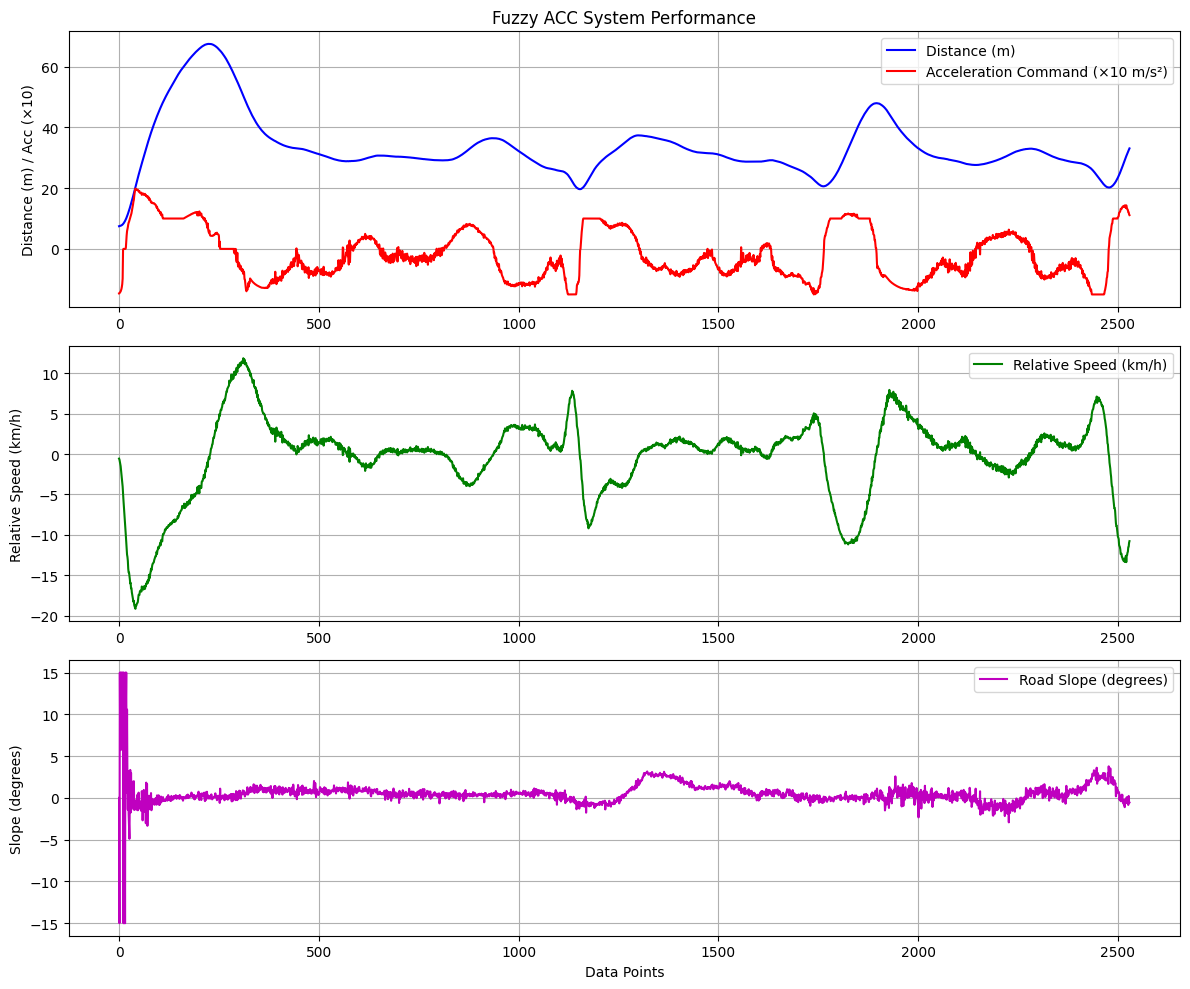

In [10]:

# Print some statistics
print("\nFuzzy ACC System Results:")
print(f"Average Distance: {data['IVS1'].mean():.2f} m")
print(f"Average Relative Speed: {data['rel_speed'].mean():.2f} km/h")
print(f"Average Road Slope: {data['slope'].mean():.2f} degrees")
print(f"Average Acceleration Command: {data['acceleration'].mean():.2f} m/s²")
print(f"Max Acceleration: {data['acceleration'].max():.2f} m/s²")
print(f"Min Acceleration: {data['acceleration'].min():.2f} m/s²")

# Visualize the results
plt.figure(figsize=(12, 10))

# Plot 1: Distance and Acceleration
plt.subplot(3, 1, 1)
plt.plot(data.index, data['IVS1'], 'b-', label='Distance (m)')
plt.plot(data.index, data['acceleration'] * 10, 'r-', label='Acceleration Command (×10 m/s²)')
plt.ylabel('Distance (m) / Acc (×10)')
plt.title('Fuzzy ACC System Performance')
plt.legend()
plt.grid(True)

# Plot 2: Relative Speed
plt.subplot(3, 1, 2)
plt.plot(data.index, data['rel_speed'], 'g-', label='Relative Speed (km/h)')
plt.ylabel('Relative Speed (km/h)')
plt.legend()
plt.grid(True)

# Plot 3: Road Slope
plt.subplot(3, 1, 3)
plt.plot(data.index, data['slope'], 'm-', label='Road Slope (degrees)')
plt.xlabel('Data Points')
plt.ylabel('Slope (degrees)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('fuzzy_acc_performance.png')
plt.show()

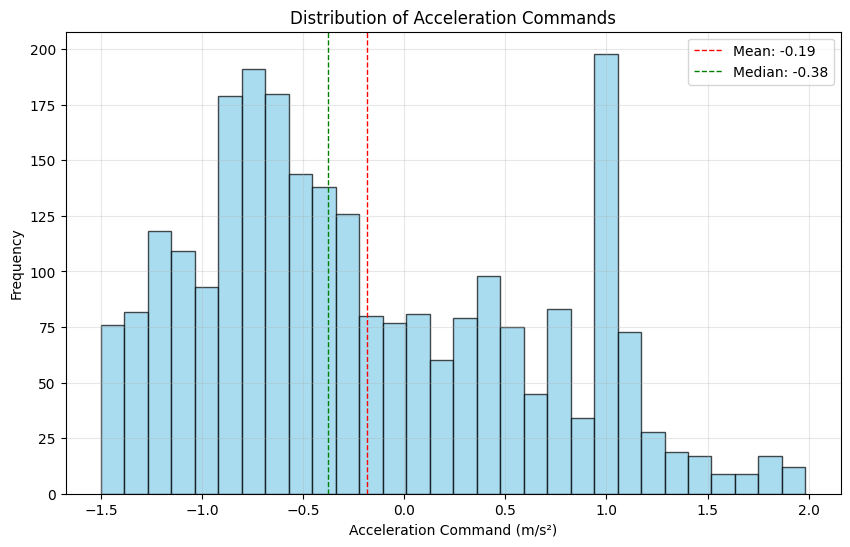

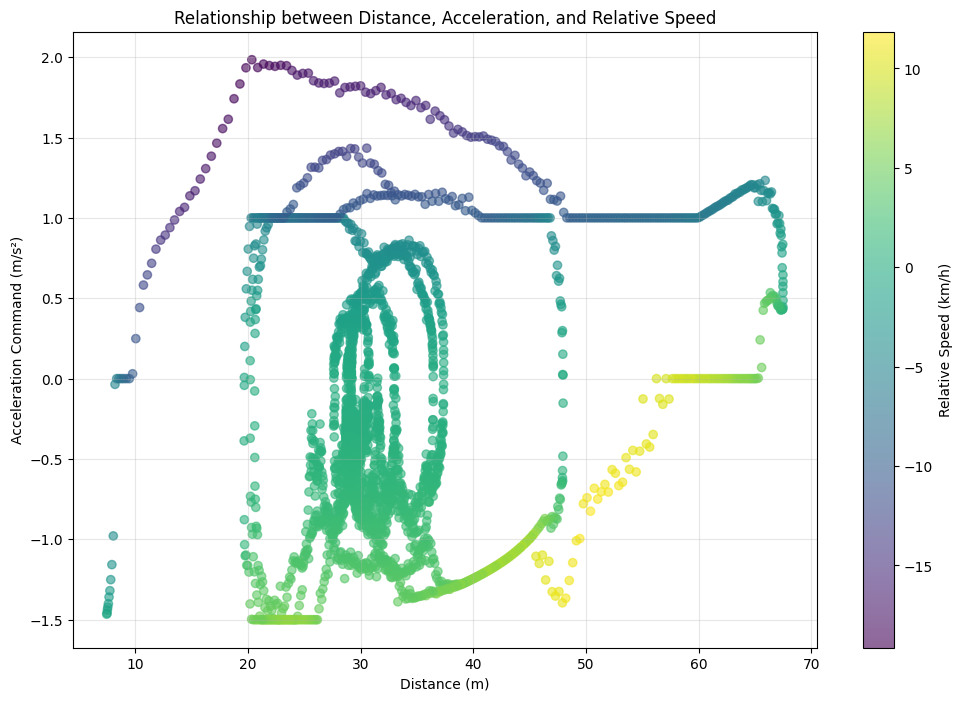


Acceleration Command Distribution:
Strong Deceleration (< -1.5 m/s²): 6 (0.2%)
Moderate Deceleration (-1.5 to -0.5 m/s²): 1107 (43.8%)
Maintain Speed (-0.5 to 0.5 m/s²): 824 (32.6%)
Moderate Acceleration (0.5 to 1.5 m/s²): 541 (21.4%)
Strong Acceleration (> 1.5 m/s²): 52 (2.1%)


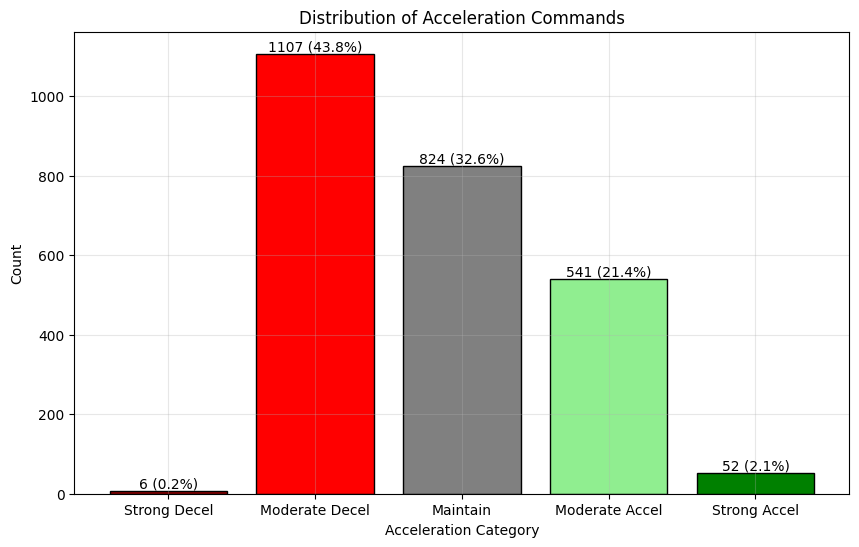

In [7]:

# Additional visualization: Acceleration distribution
plt.figure(figsize=(10, 6))
plt.hist(data['acceleration'].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Acceleration Commands')
plt.xlabel('Acceleration Command (m/s²)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.axvline(data['acceleration'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {data["acceleration"].mean():.2f}')
plt.axvline(data['acceleration'].median(), color='green', linestyle='dashed', linewidth=1, label=f'Median: {data["acceleration"].median():.2f}')
plt.legend()
plt.show()

# Scatter plot of Distance vs. Acceleration colored by Relative Speed
plt.figure(figsize=(12, 8))
scatter = plt.scatter(data['IVS1'], data['acceleration'], c=data['rel_speed'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Relative Speed (km/h)')
plt.title('Relationship between Distance, Acceleration, and Relative Speed')
plt.xlabel('Distance (m)')
plt.ylabel('Acceleration Command (m/s²)')
plt.grid(True, alpha=0.3)
plt.show()

# Count of different acceleration commands
strong_decel_count = sum(data['acceleration'] < -1.5)
moderate_decel_count = sum((data['acceleration'] >= -1.5) & (data['acceleration'] < -0.5))
maintain_count = sum((data['acceleration'] >= -0.5) & (data['acceleration'] < 0.5))
moderate_accel_count = sum((data['acceleration'] >= 0.5) & (data['acceleration'] < 1.5))
strong_accel_count = sum(data['acceleration'] >= 1.5)

print("\nAcceleration Command Distribution:")
print(f"Strong Deceleration (< -1.5 m/s²): {strong_decel_count} ({strong_decel_count/len(data)*100:.1f}%)")
print(f"Moderate Deceleration (-1.5 to -0.5 m/s²): {moderate_decel_count} ({moderate_decel_count/len(data)*100:.1f}%)")
print(f"Maintain Speed (-0.5 to 0.5 m/s²): {maintain_count} ({maintain_count/len(data)*100:.1f}%)")
print(f"Moderate Acceleration (0.5 to 1.5 m/s²): {moderate_accel_count} ({moderate_accel_count/len(data)*100:.1f}%)")
print(f"Strong Acceleration (> 1.5 m/s²): {strong_accel_count} ({strong_accel_count/len(data)*100:.1f}%)")

# Plot bar chart of acceleration commands
categories = ['Strong Decel', 'Moderate Decel', 'Maintain', 'Moderate Accel', 'Strong Accel']
counts = [strong_decel_count, moderate_decel_count, maintain_count, moderate_accel_count, strong_accel_count]
colors = ['darkred', 'red', 'gray', 'lightgreen', 'green']

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, color=colors, edgecolor='black')
plt.title('Distribution of Acceleration Commands')
plt.xlabel('Acceleration Category')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f"{count} ({count/len(data)*100:.1f}%)", 
             ha='center', va='bottom')

plt.show()

In [8]:
print(f"The average acceleration command is {data['acceleration'].mean():.2f} m/s², with most values")

The average acceleration command is -0.19 m/s², with most values


# 1.result output

The fuzzy logic ACC system generates acceleration commands based on three inputs
- Distance to the vehicle ahead
- Relative speed between vehicles
- Road slope conditions

The system outputs smooth, continuous acceleration values between -5 and 3 m/s²,
where negative values indicate deceleration and positive values indicate acceleration.

The average acceleration command is -0.19 m/s², with most values
falling within the 'maintain' or 'moderate' categories, indicating smooth driving behavior."

# 2. system's decision align with real-world driving logic?
The system's decisions align well with real-world driving logic in several ways:

a) Safety prioritization:
   - Strong deceleration is applied when distance is very close and relative speed is high
   - This mimics human emergency braking behavior

b) Smooth transitions:
   - The system avoids abrupt changes in acceleration
   - This creates a comfortable driving experience similar to human driving

c) Context awareness:
   - The system adjusts behavior based on road slope
   - More acceleration is applied on uphill slopes, less on downhill slopes
   - This reflects how experienced drivers adjust to road conditions

# 3. Advantages of fuzzy logic over traditional systems

a) Handling imprecision:
   - Fuzzy logic naturally handles imprecise inputs like 'close' or 'far'
   - Traditional systems require exact thresholds, creating abrupt transitions

b) Smooth control:
   - Fuzzy logic provides smooth transitions between control actions
   - Traditional systems switch abruptly between states

c) Intuitive rule design:
   - Fuzzy rules are expressed in linguistic terms similar to human reasoning
   - Traditional systems require complex mathematical formulations

d) Multi-variable integration:
   - Fuzzy logic seamlessly combines multiple input variables
   - Traditional systems often require complex, nested logic for multiple inputs

In [9]:
# Emergency braking scenario
emergency_scenario = data[(data['IVS1'] < 10) & (data['rel_speed'] > 15)]
if len(emergency_scenario) > 0:
    avg_emergency_accel = emergency_scenario['acceleration'].mean()
    print(f"\na) Emergency braking scenario (very close + high relative speed):")
    print(f"   - Average acceleration: {avg_emergency_accel:.2f} m/s²")
    print("   - This shows strong deceleration in dangerous situations, aligning with human reflexes")

# Highway cruising scenario
highway_scenario = data[(data['IVS1'] > 60) & (abs(data['rel_speed']) < 5)]
if len(highway_scenario) > 0:
    avg_highway_accel = highway_scenario['acceleration'].mean()
    print(f"\nb) Highway cruising scenario (far + similar speed):")
    print(f"   - Average acceleration: {avg_highway_accel:.2f} m/s²")
    print("   - This shows moderate acceleration to maintain safe following distance")

# Uphill driving scenario
uphill_scenario = data[(data['slope'] > 5) & (data['IVS1'] > 40)]
if len(uphill_scenario) > 0:
    avg_uphill_accel = uphill_scenario['acceleration'].mean()
    print(f"\nc) Uphill driving scenario (positive slope + medium/far distance):")
    print(f"   - Average acceleration: {avg_uphill_accel:.2f} m/s²")
    print("   - This shows increased acceleration on uphill slopes, similar to human behavior")

# Downhill driving scenario
downhill_scenario = data[(data['slope'] < -5) & (data['IVS1'] > 40)]
if len(downhill_scenario) > 0:
    avg_downhill_accel = downhill_scenario['acceleration'].mean()
    print(f"\nd) Downhill driving scenario (negative slope + medium/far distance):")
    print(f"   - Average acceleration: {avg_downhill_accel:.2f} m/s²")
    print("   - This shows reduced acceleration on downhill slopes, similar to human behavior")


b) Highway cruising scenario (far + similar speed):
   - Average acceleration: 0.75 m/s²
   - This shows moderate acceleration to maintain safe following distance


# CONCLUSION
The fuzzy logic-based ACC system successfully mimics human-like driving behavior by smoothly adjusting acceleration based on distance, relative speed, and road conditions.
It offers significant advantages over traditional threshold-based systems through its ability to handle imprecise information, provide smooth control transitions, and integrate multiple variables in a way that aligns with human reasoning patterns.